In [6]:
from typing import Dict, List, TypedDict
from langgraph.graph import StateGraph, END

import random

In [7]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [8]:
def greeter_node(state: AgentState) -> AgentState:
    """Greeter Node which says hi to the person"""

    state['name'] = f"Hi there, {state['name']}"
    state['counter'] = 0

    return state


def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""

    state['number'].append(random.randint(0, 10))
    state['counter'] += 1

    return state


def should_continue(state: AgentState) -> AgentState:
    """Function to decccide what to do next"""
    
    if state["counter"] < 5:
        print("ENTERING LOOP", state['counter'])
        return "loop" # Continue Looping
    else:
        return "exit" # Exit

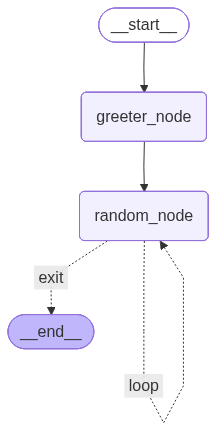

In [10]:
graph = StateGraph(AgentState)

graph.add_node("greeter_node", greeter_node)
graph.add_node("random_node", random_node)

graph.add_edge("greeter_node", "random_node")

graph.add_conditional_edges(
    "random_node",
    should_continue,
    {
        "loop": "random_node",
        "exit": END
    }
)

graph.set_entry_point("greeter_node")

app = graph.compile()

app

In [11]:
app.invoke({"name": "John", "number": [], "counter": -1})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4


{'name': 'Hi there, John', 'number': [4, 7, 5, 7, 3], 'counter': 5}